In [1]:

!pip -q install kagglehub seaborn

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [2]:

def read_csv_safe(file_path):
    encodings = ['utf-8', 'utf-8-sig', 'latin1', 'cp1252', 'ISO-8859-1']
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f'Файл успішно прочитано з кодуванням: {enc}')
            return df
        except Exception as e:
            last_error = e
    raise last_error

def find_csv_file(path):
    csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError('CSV-файл не знайдено.')
    print('CSV files:', csv_files)
    return os.path.join(path, csv_files[0])


## 1. Завантаження датасету

In [3]:

path = kagglehub.dataset_download("chaerultkarim/museum-visitors-for-visualization")
print("Path to dataset files:", path)
print("Files in dataset folder:", os.listdir(path))

csv_file = find_csv_file(path)
df = read_csv_safe(csv_file)


100%|██████████| 1.07k/1.07k [00:00<00:00, 1.65MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/chaerultkarim/museum-visitors-for-visualization/versions/2
Files in dataset folder: ['museum_visitors.csv']
CSV files: ['museum_visitors.csv']
Файл успішно прочитано з кодуванням: utf-8


## 2. Перші 5 рядків датасету

In [4]:
display(df.head())

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


## 3. Попередній аналіз даних

In [5]:

print("Розмір датасету:", df.shape)
print("\nТипи даних:")
print(df.dtypes)
print("\nКількість пропусків:")
print(df.isna().sum())


Розмір датасету: (59, 5)

Типи даних:
Date                                    object
Avila Adobe                              int64
Firehouse Museum                         int64
Chinese American Museum                  int64
America Tropical Interpretive Center     int64
dtype: object

Кількість пропусків:
Date                                    0
Avila Adobe                             0
Firehouse Museum                        0
Chinese American Museum                 0
America Tropical Interpretive Center    0
dtype: int64


## 4. Перевірка дублікатів

In [6]:

print("Кількість дублікатів:", df.duplicated().sum())
df = df.drop_duplicates()
print("Розмір таблиці без дублікатів:", df.shape)


Кількість дублікатів: 0
Розмір таблиці без дублікатів: (59, 5)


## 5. Роки, про які містить інформацію датасет

In [7]:

df['Date'] = pd.to_datetime(df['Date'])
print("Роки в датасеті:", sorted(df['Date'].dt.year.unique()))


Роки в датасеті: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


## 6. Зміна назв стовпців

In [8]:

print("Початкові назви стовпців:", df.columns.tolist())
print("Кількість стовпців:", len(df.columns))

df.columns = [
    'date',
    'avila_adobe',
    'firehouse_museum',
    'chinese_american_museum',
    'america_tropical_interpretive_center'
]

print("Нові назви стовпців:", df.columns.tolist())
display(df.head())


Початкові назви стовпців: ['Date', 'Avila Adobe', 'Firehouse Museum', 'Chinese American Museum', 'America Tropical Interpretive Center']
Кількість стовпців: 5
Нові назви стовпців: ['date', 'avila_adobe', 'firehouse_museum', 'chinese_american_museum', 'america_tropical_interpretive_center']


,date,avila_adobe,firehouse_museum,chinese_american_museum,america_tropical_interpretive_center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694


## Додаткова підготовка даних

In [9]:

museum_cols = [
    'avila_adobe',
    'firehouse_museum',
    'chinese_american_museum',
    'america_tropical_interpretive_center'
]

for col in museum_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

display(df.head())


,date,avila_adobe,firehouse_museum,chinese_american_museum,america_tropical_interpretive_center,year,month,month_name
0,2014-01-01,24778,4486,1581,6602,2014,1,January
1,2014-02-01,18976,4172,1785,5029,2014,2,February
2,2014-03-01,25231,7082,3229,8129,2014,3,March
3,2014-04-01,26989,6756,2129,2824,2014,4,April
4,2014-05-01,36883,10858,3676,10694,2014,5,May


## 7. Середня кількість відвідувачів для кожного музею

In [10]:

mean_visitors = df[museum_cols].mean()
print("Середня кількість відвідувачів для кожного музею:")
print(mean_visitors)


Середня кількість відвідувачів для кожного музею:
avila_adobe                             24061.661017
firehouse_museum                         6472.830508
chinese_american_museum                  2721.254237
america_tropical_interpretive_center     7107.016949
dtype: float64


## 8. Мінімальна та максимальна кількість відвідувачів для кожного музею за 2018 рік

In [11]:

df_2018 = df[df['year'] == 2018]
min_max_2018 = df_2018[museum_cols].agg(['min', 'max']).T
print("Мінімальна та максимальна кількість відвідувачів у 2018 році:")
display(min_max_2018)


Мінімальна та максимальна кількість відвідувачів у 2018 році:


,min,max
avila_adobe,14718,25173
firehouse_museum,3306,8013
chinese_american_museum,2146,4960
america_tropical_interpretive_center,3180,5837


## 9. Місяці з найвищою і найнижчою загальною кількістю відвідувачів у 2015 році

In [12]:

df_2015 = df[df['year'] == 2015].copy()
df_2015['total_visitors'] = df_2015[museum_cols].sum(axis=1)

max_month = df_2015.loc[df_2015['total_visitors'].idxmax(), 'month_name']
min_month = df_2015.loc[df_2015['total_visitors'].idxmin(), 'month_name']

print("Місяць з найвищою загальною кількістю відвідувачів у 2015 році:", max_month)
print("Місяць з найнижчою загальною кількістю відвідувачів у 2015 році:", min_month)


Місяць з найвищою загальною кількістю відвідувачів у 2015 році: May
Місяць з найнижчою загальною кількістю відвідувачів у 2015 році: February


## 10. Порівняння кількості відвідувачів музею Avila Adobe у літні і зимові місяці 2018 року

In [13]:

summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

avila_summer_2018 = df_2018[df_2018['month'].isin(summer_months)]['avila_adobe']
avila_winter_2018 = df_2018[df_2018['month'].isin(winter_months)]['avila_adobe']

print("Середня кількість відвідувачів Avila Adobe влітку 2018:", avila_summer_2018.mean())
print("Середня кількість відвідувачів Avila Adobe взимку 2018:", avila_winter_2018.mean())

if avila_summer_2018.mean() > avila_winter_2018.mean():
    print("Влітку 2018 року музей Avila Adobe відвідували більше, ніж взимку.")
elif avila_summer_2018.mean() < avila_winter_2018.mean():
    print("Взимку 2018 року музей Avila Adobe відвідували більше, ніж влітку.")
else:
    print("Середня відвідуваність однакова.")


Середня кількість відвідувачів Avila Adobe влітку 2018: 22040.666666666668
Середня кількість відвідувачів Avila Adobe взимку 2018: 15491.5
Влітку 2018 року музей Avila Adobe відвідували більше, ніж взимку.


## 11. Кореляція між кількістю відвідувачів у музеях та датами у 2016 році

In [14]:

df_2016 = df[df['year'] == 2016].copy()
df_2016['date_ordinal'] = df_2016['date'].map(pd.Timestamp.toordinal)

correlations_2016 = df_2016[museum_cols + ['date_ordinal']].corr()['date_ordinal'].drop('date_ordinal')
print("Кореляція між датами і кількістю відвідувачів у 2016 році:")
print(correlations_2016)


Кореляція між датами і кількістю відвідувачів у 2016 році:
avila_adobe                             0.060350
firehouse_museum                       -0.201650
chinese_american_museum                -0.415031
america_tropical_interpretive_center   -0.228172
Name: date_ordinal, dtype: float64


## 12. Лінійний графік: відвідуваність Avila Adobe з часом

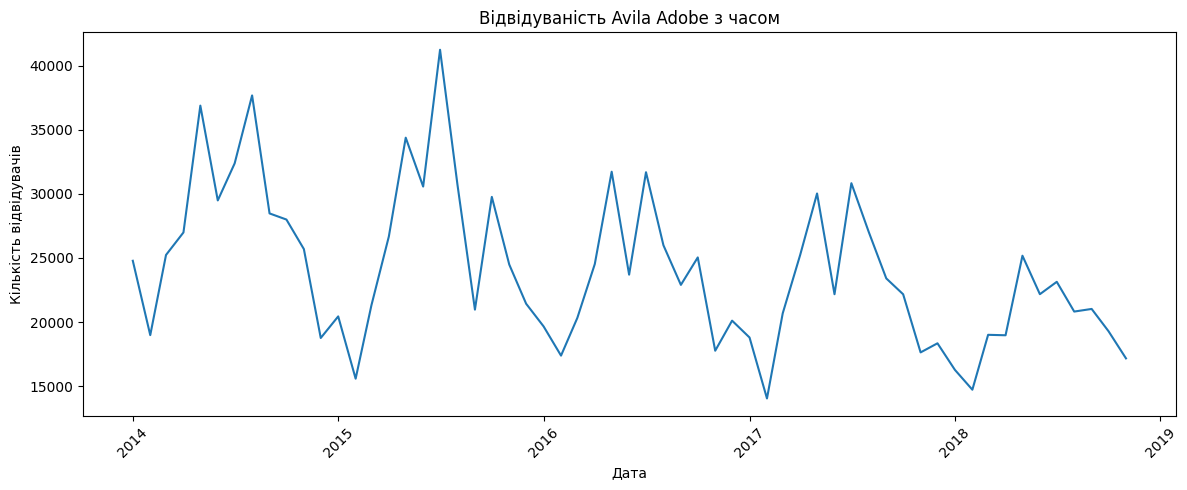

In [15]:

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['avila_adobe'])
plt.title('Відвідуваність Avila Adobe з часом')
plt.xlabel('Дата')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Boxplot: розподіл відвідувачів Chinese American Museum по роках

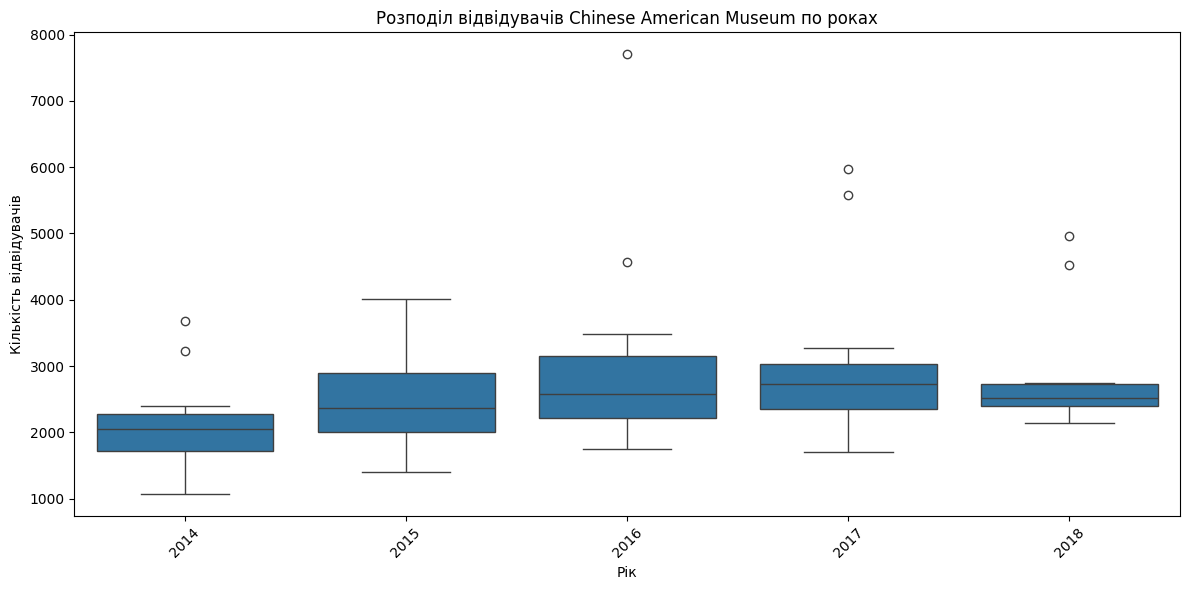

In [16]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='chinese_american_museum')
plt.title('Розподіл відвідувачів Chinese American Museum по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Heatmap: кореляція між музеями

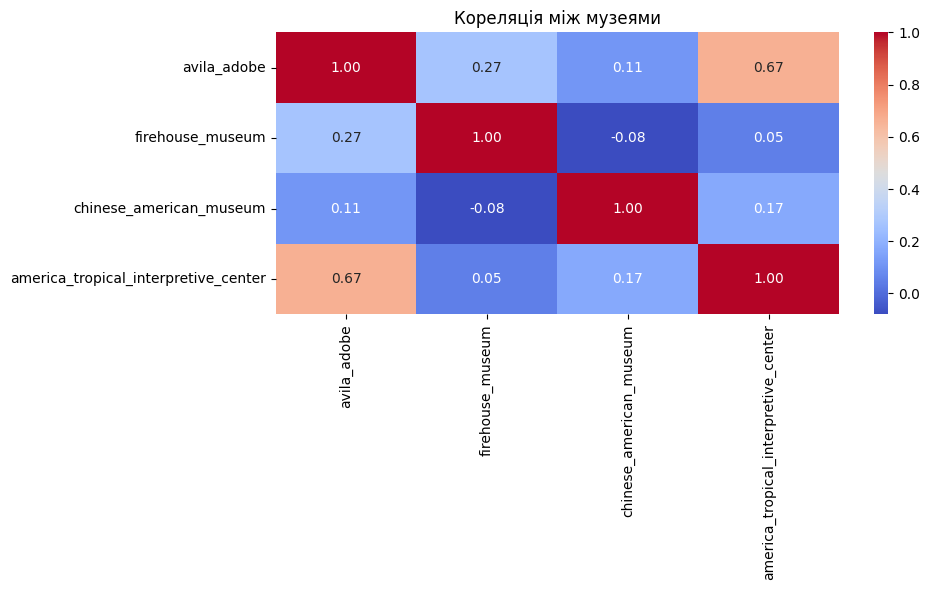

In [17]:

plt.figure(figsize=(10, 6))
sns.heatmap(df[museum_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляція між музеями')
plt.tight_layout()
plt.show()


## 14. Histogram

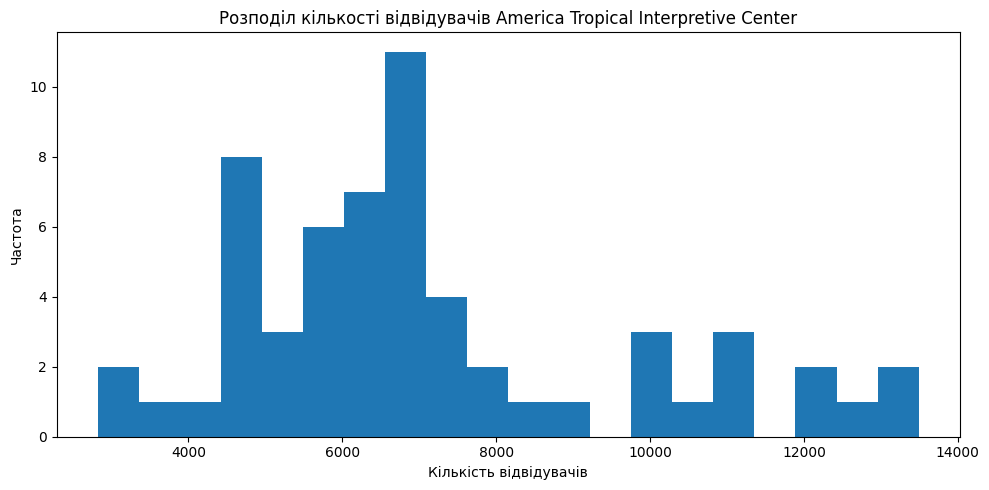

In [18]:

# У наявному датасеті немає стовпця gateway_to_nature_center,
# тому гістограму будуємо для America Tropical Interpretive Center
plt.figure(figsize=(10, 5))
plt.hist(df['america_tropical_interpretive_center'].dropna(), bins=20)
plt.title('Розподіл кількості відвідувачів America Tropical Interpretive Center')
plt.xlabel('Кількість відвідувачів')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()


## 15. Barplot: середня кількість відвідувачів по музеях за всі роки

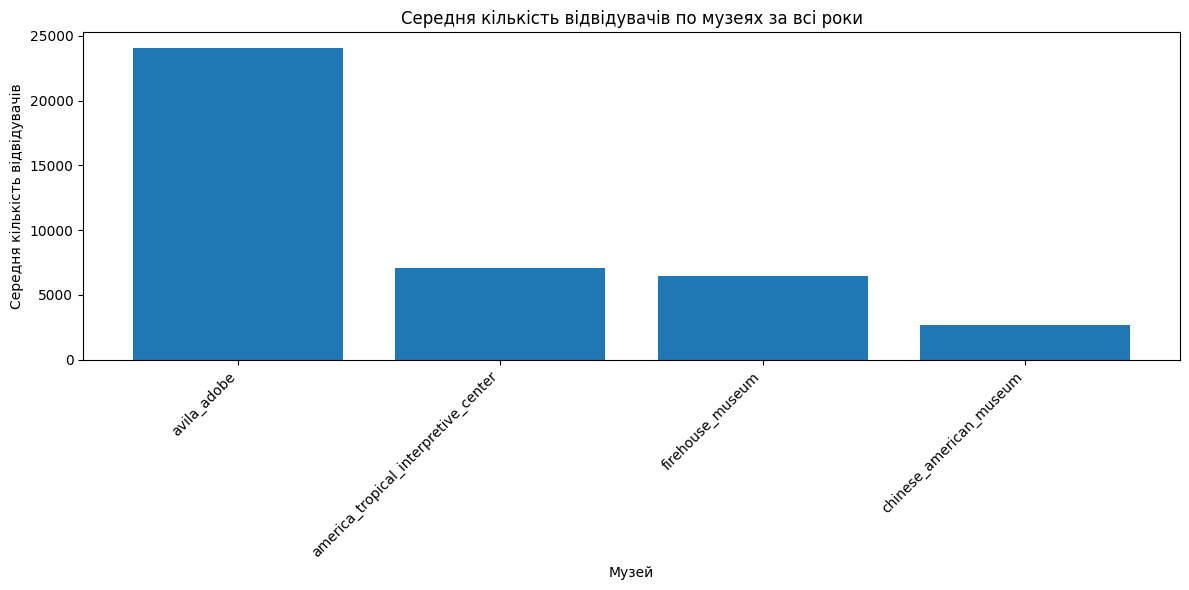

In [19]:

mean_visitors_sorted = mean_visitors.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(mean_visitors_sorted.index, mean_visitors_sorted.values)
plt.title('Середня кількість відвідувачів по музеях за всі роки')
plt.xlabel('Музей')
plt.ylabel('Середня кількість відвідувачів')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Висновки


У ході виконання лабораторної роботи було проведено аналіз датасету з відвідуваністю музеїв.  
Було виконано попередній аналіз структури даних, перевірено типи стовпців, кількість пропусків і дублікатів, а також проведено підготовку даних до аналізу.
